In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import itertools
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
import liset_data_reader.lists_sessions as lists_sessions
import dutta_test.utils as utils
# Set style
sns.set_style("whitegrid")
# plt.rcParams.update({'font.size': 12})
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
# Load Data
results_path = os.path.join("cnn_detections", "all_networks_metrics_liset.csv")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in df.columns:
        df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", df.columns.tolist())
    print("Threshold:", sorted(df["Threshold"].unique()))
    
    display(df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 216 rows from cnn_detections\all_networks_metrics_liset.csv
Columns: ['Session', 'Channel', 'Threshold', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples', 'Duration_min']
Threshold: [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]


,Session,Channel,Threshold,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples,Duration_min
0,2025-09-24_14-22-55,25,0.3,259,37,5,0.875000,0.981061,0.925000,7.943758,1561,264,6.399817
1,2025-09-24_10-24-40,30,0.3,51,188,41,0.213389,0.554348,0.308157,22.577778,398,92,10.413202
2,2025-09-25_12-52-22,25,0.3,14,196,34,0.066667,0.291667,0.108527,45.276190,682,48,10.408512
3,2025-09-24_11-34-51,30,0.3,61,176,10,0.257384,0.859155,0.396104,18.681967,517,71,6.631565
4,2025-09-24_15-13-10,14,0.3,59,6,25,0.907692,0.702381,0.791946,21.240678,162,84,5.505123


In [4]:
hfo_sessions = lists_sessions.HFO_sessions
ripple_sessions = lists_sessions.Ripple_sessions

sessions_to_reject={
    # "2025-09-24_16-29-07", #R   # Nothing concrete to reject here
        "2025-09-24_17-38-17", # Barely any ripples (14 in total...)
        "2025-09-25_12-52-22", # Not a good session to detect ripples
        #  "2025-09-24_11-34-51",
        } #R 
# og_session_set={"2025-09-22_17-55-26", #R
# #                 "2025-09-23_15-50-26", #R
# #                 "2025-09-24_10-24-40", #R
# #                 "2025-09-24_14-22-55", #H
# #                 "2025-09-24_15-13-10", #H
# #                 "2025-09-25_16-41-14"} #R    
# }
sessions_to_reject.update(hfo_sessions)

    # df=df[df["Session"].isin(og_session_set)]

    # # New sessions:

    

df=df[~df["Session"].isin(sessions_to_reject)]
print(df["Session"].unique())
# df=df[~df["Session"].isin(ripple_sessions)]

['2025-09-24_10-24-40' '2025-09-24_11-34-51' '2025-09-23_15-50-26'
 '2025-09-24_16-29-07' '2025-09-22_17-55-26' '2025-09-22_17-42-27'
 '2025-09-25_11-21-53' '2025-09-25_16-41-14' '2025-09-23_16-17-52'
 'Calbai32FPGA_251003_150055' 'PV01ai32FPGA_250611_115923'
 'Calbai32FPGA_251003_144832' 'PV01ai32FPGA_250611_122326'
 'Calb_251209_160255' 'Calb_251210_164150' 'Calb_251211_105518'
 'Calb_251211_104316' 'Calb_251210_122327' 'Calb_251210_115904'
 'Calb_251210_165332' 'Calb_251211_110650' 'Calb_251210_121141'
 'Calb_251210_162849']


In [5]:
# Print summary
print("\n--- Summary by Threshold ---")
summary = df.groupby("Threshold")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].median().round(3).sort_values(by="F1", ascending=False)
display(summary)


--- Summary by Threshold ---


,F1,Precision,Recall,TP,FP,FN
Threshold,,,,,,
0.7,0.600,0.582,0.635,57.0,23.0,39.0
0.8,0.591,0.684,0.510,48.0,12.0,51.0
0.6,0.525,0.517,0.720,62.0,42.0,29.0
0.9,0.508,0.850,0.349,31.0,4.0,72.0
0.5,0.476,0.443,0.788,70.0,72.0,23.0
0.4,0.474,0.343,0.822,83.0,118.0,16.0
0.3,0.418,0.279,0.886,88.0,189.0,10.0
1.0,0.000,0.000,0.000,0.0,0.0,109.0


In [6]:
print(summary.loc[summary["F1"].idxmax()])

F1            0.600
Precision     0.582
Recall        0.635
TP           57.000
FP           23.000
FN           39.000
Name: 0.7, dtype: float64


In [7]:
# Print summary
print("\n--- Summary by Session ---")
for threshold in df["Threshold"].unique():
    print(f"\nThreshold: {threshold}")
    summary = df[df["Threshold"]==threshold].groupby("Session")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].mean().round(3).sort_values(by="F1", ascending=False)
    display(summary)
    print(f"Number of sessions:{len(summary)}")



--- Summary by Session ---

Threshold: 0.3


,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
2025-09-22_17-55-26,0.706,0.597,0.865,160.0,108.0,25.0
Calb_251210_165332,0.675,0.562,0.846,77.0,60.0,14.0
Calb_251209_160255,0.622,0.491,0.848,56.0,58.0,10.0
2025-09-22_17-42-27,0.613,0.494,0.807,88.0,90.0,21.0
2025-09-23_15-50-26,0.553,0.458,0.698,97.0,115.0,42.0
2025-09-25_11-21-53,0.518,0.512,0.525,106.0,101.0,96.0
Calb_251211_105518,0.508,0.347,0.947,124.0,233.0,7.0
Calb_251210_164150,0.499,0.351,0.864,102.0,189.0,16.0
2025-09-25_16-41-14,0.498,0.691,0.389,56.0,25.0,88.0


Number of sessions:23

Threshold: 0.4


,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
2025-09-22_17-55-26,0.747,0.722,0.773,143.0,55.0,42.0
Calb_251210_165332,0.731,0.679,0.791,72.0,34.0,19.0
2025-09-22_17-42-27,0.680,0.615,0.761,83.0,52.0,26.0
Calb_251209_160255,0.649,0.568,0.758,50.0,38.0,16.0
Calb_251210_164150,0.593,0.464,0.822,97.0,112.0,21.0
Calb_251211_104316,0.586,0.438,0.885,92.0,118.0,12.0
2025-09-23_15-50-26,0.579,0.606,0.554,77.0,50.0,62.0
Calb_251211_105518,0.566,0.413,0.901,118.0,168.0,13.0
2025-09-25_11-21-53,0.512,0.630,0.431,87.0,51.0,115.0


Number of sessions:23

Threshold: 0.5


...

Number of sessions:23

Threshold: 0.9


,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
Calbai32FPGA_251003_150055,0.662,0.581,0.769,143.0,103.0,43.0
Calb_251210_162849,0.653,0.788,0.558,63.0,17.0,50.0
Calb_251211_110650,0.630,0.850,0.500,34.0,6.0,34.0
Calbai32FPGA_251003_144832,0.600,0.723,0.513,99.0,38.0,94.0
PV01ai32FPGA_250611_122326,0.595,0.800,0.473,80.0,20.0,89.0
Calb_251210_115904,0.584,0.788,0.464,26.0,7.0,30.0
Calb_251211_105518,0.567,0.873,0.420,55.0,8.0,76.0
Calb_251210_164150,0.554,0.958,0.390,46.0,2.0,72.0
Calb_251210_121141,0.528,0.757,0.406,28.0,9.0,41.0


Number of sessions:23

Threshold: 1.0


,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
2025-09-22_17-42-27,0.0,0.0,0.0,0.0,0.0,109.0
Calb_251210_122327,0.0,0.0,0.0,0.0,0.0,91.0
PV01ai32FPGA_250611_115923,0.0,0.0,0.0,0.0,0.0,210.0
Calbai32FPGA_251003_150055,0.0,0.0,0.0,0.0,0.0,186.0
Calbai32FPGA_251003_144832,0.0,0.0,0.0,0.0,0.0,193.0
Calb_251211_110650,0.0,0.0,0.0,0.0,0.0,68.0
Calb_251211_105518,0.0,0.0,0.0,0.0,0.0,131.0
Calb_251211_104316,0.0,0.0,0.0,0.0,0.0,104.0
Calb_251210_165332,0.0,0.0,0.0,0.0,0.0,91.0


Number of sessions:23


In [8]:
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values. 
    Adapted from the provided script.
    """
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        text = ''
        p = .05
        while data < p:
            text += '*'
            p /= 10.
            if maxasterix and len(text) == maxasterix:
                break
        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

C:\Users\NCN\AppData\Local\Temp\ipykernel_13048\2457553838.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.8, inner="quart", cut=0, order=adapt_values)


N=23 matched samples for statistics.
0.3 vs 0.4: p=0.0003 True
0.3 vs 0.5: p=0.0190 True
0.3 vs 0.6: p=0.0176 True
0.3 vs 0.7: p=0.1157 False
0.3 vs 0.8: p=0.8822 False
0.3 vs 0.9: p=1.0000 False
0.4 vs 0.5: p=0.1118 False
0.4 vs 0.6: p=0.2542 False
0.4 vs 0.7: p=0.8822 False
0.4 vs 0.8: p=1.0000 False
0.4 vs 0.9: p=1.0000 False
0.5 vs 0.6: p=0.8822 False
0.5 vs 0.7: p=1.0000 False
0.5 vs 0.8: p=1.0000 False
0.5 vs 0.9: p=0.3920 False
0.6 vs 0.7: p=1.0000 False
0.6 vs 0.8: p=1.0000 False
0.6 vs 0.9: p=0.0694 False
0.7 vs 0.8: p=0.8822 False
0.7 vs 0.9: p=0.0026 True
0.8 vs 0.9: p=0.0026 True


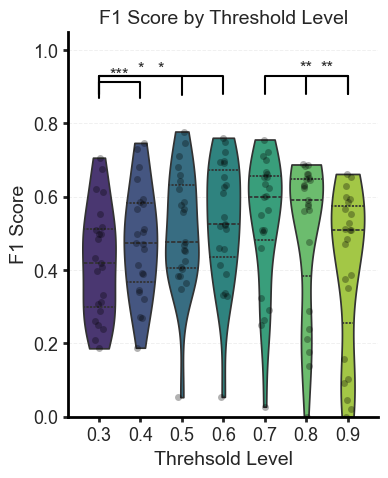

In [9]:
from snnTorch.generalization_madrid.utils import holm_bonferroni

# Define shared color palette for consistency across plots
# Get viridis colors based on number of thresholds (will be determined dynamically)
def get_threshold_colors(adapt_values):
    """Get consistent viridis colors for thresholds."""
    return sns.color_palette("viridis", len(adapt_values))

def plot_f1_boxplot_by_adapt(df, metric="F1", aggregate_by_network=False,figsize=(5,6),thresholds_to_include=None):
    # Define specific order
    # desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Threshold"].unique()]
    adapt_values = sorted(df["Threshold"].unique()) if thresholds_to_include is None else sorted(thresholds_to_include)
    # Data preparation
    if aggregate_by_network:
        # Average over sessions/channels for each network
        plot_df = df.groupby(["Network", "Threshold"])[metric].mean().reset_index()
        title_suffix = " (Averaged by Network)"
        print(f"Aggregated by network. N={len(plot_df['Network'].unique())} networks.")
    else:
        plot_df = df
        title_suffix = ""

    fig, ax = plt.subplots(figsize=figsize)
    
    # Boxplot
    # sns.boxplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)
    sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.8, inner="quart", cut=0, order=adapt_values)
    sns.stripplot(x="Threshold", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session", "Channel",]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Threshold", values=metric)
    pivot = pivot.dropna()
    print(f"N={len(pivot)} matched samples for statistics.")
    p_values=[]
    pairs=[]
    if len(pivot) > 0:
        centers = range(len(adapt_values))
        # Calculate max height for annotations
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3:
                stat, p = wilcoxon(v1, v2)
                p_values.append(p)
                pairs.append((a1, a2))

                
                # Stacking logic for brackets
                # h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                # print(f"{a1} vs {a2}: p={p:.4f}")
                # barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
            
        corrected_significant, adjusted_pvals=utils.holm_bonferroni(p_values,alpha=0.05)
        for p,sig,(b1,b2) in zip(adjusted_pvals,corrected_significant,pairs):        
                print(f"{b1} vs {b2}: p={p:.4f} {sig}")          
                barplot_annotate_brackets(adapt_values.index(b1), adapt_values.index(b2), p, centers, [max_val+0.05]*len(centers), ax, fs=12, maxasterix=3)   

    ax.grid(True, axis='y', linestyle='--',linewidth=0.7,alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)   
   
    ax.set_title(f"{metric} Score by Threshold Level{title_suffix}",fontsize=14)
    ax.set_ylim(0, 1.05) # Adjust to fit brackets
    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Threhsold Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2.0)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')

    plt.show()
    return fig,ax
if 'df' in locals():
   fig,ax = plot_f1_boxplot_by_adapt(df, "F1", aggregate_by_network=False,figsize=(4,5),thresholds_to_include=[0.3,0.4,0.5,0.6,0.7,0.8,0.9])
   fig.savefig(os.path.join("figures", "f1_by_threshold_boxplot.svg"), format="svg", bbox_inches="tight")

Precision    Recall
Threshold                          
0.3       0.25   0.193089  0.826747
          0.50   0.279104  0.885714
          0.75   0.492805  0.951304
0.4       0.25   0.255914  0.759522
          0.50   0.343396  0.822034

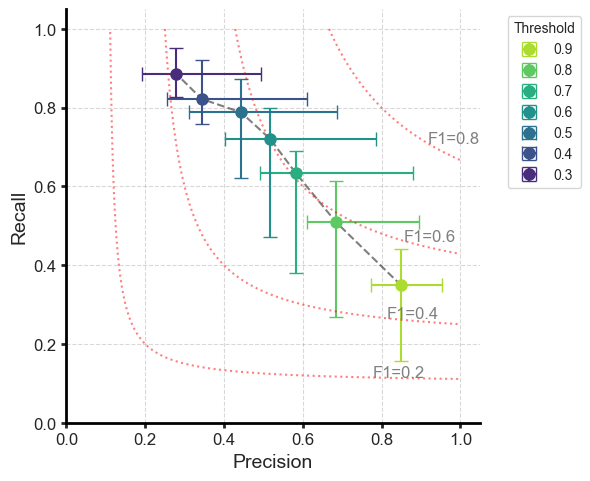

In [10]:
def plot_precision_recall_curve(df, thresholds_to_include=None):
    # Filter for specific buffer size if needed, e.g., buffer=6

    mask=(df["Threshold"].isin(thresholds_to_include)) 
    df_subset = df[mask].copy()
    
    # Calculate median (50%), 25%, and 75% quantiles
    summary = df_subset.groupby("Threshold")[["Precision", "Recall"]].quantile([0.25, 0.5, 0.75]) # one row per threshold per quantile
    display(summary.head())
    # Sort index appropriately for plotting logic
    # Unstack to get columns like (Precision, 0.5), (Precision, 0.25) ...
    summary = summary.unstack(level=1) # create multi-index columns # Metric, Quantile
    # display(summary.head()  )
    # Extract Medians as the central point
    means = summary.xs(0.5, axis=1, level=1).sort_index(ascending=False) # Extract median values (Threshold, Metric)
    # display(means.head())

    # Calculate IQR errors:
    # lower_err = median - Q1
    # upper_err = Q3 - median
    q1 = summary.xs(0.25, axis=1, level=1).sort_index(ascending=False) # Extract Q1 values (Threshold, Metric)
    q3 = summary.xs(0.75, axis=1, level=1).sort_index(ascending=False) # Extract Q3 values (Threshold, Metric)
    
    # Define errors for errorbar plot (shape: 2xN for each point [lower, upper])
    # Precision Errors
    prec_err_lower = means["Precision"] - q1["Precision"]
    prec_err_upper = q3["Precision"] - means["Precision"]
    
    # Recall Errors
    rec_err_lower = means["Recall"] - q1["Recall"]
    rec_err_upper = q3["Recall"] - means["Recall"]
    
    thresholds = means.index.values

    fig,ax=plt.subplots(figsize=(6,6))
    
    # Plot the line connecting the medians
    ax.plot(means["Precision"], means["Recall"], 'k--', alpha=0.5)
    
    # Plot points with IQR error bars
    sorted_thresholds = sorted(thresholds)
    # Use same viridis colors as cell 8
    colors = get_threshold_colors(sorted_thresholds)
    color_map = {th: col for th, col in zip(sorted_thresholds, colors)}
    
    for i, th in enumerate(thresholds):
        # Prepare error arrays (needs to be sequence of shape (2, 1) or scalar if symmetric, but here asymmetric)
        xerr = [[prec_err_lower[th]], [prec_err_upper[th]]]
        yerr = [[rec_err_lower[th]], [rec_err_upper[th]]]
        
        ax.errorbar(means.loc[th, "Precision"], means.loc[th, "Recall"], 
                     xerr=xerr, 
                     yerr=yerr, 
                     fmt='o', color=color_map[th], 
                     capsize=5, label=f'{th}', markersize=8)

    # Add F1 isolines for reference
    f1_scores = [0.2, 0.4, 0.6, 0.8]
    x = np.linspace(0, 1, 10000)
    for f1 in f1_scores:
        y = (f1 * x) / (2 * x - f1)
        valid = (y > 0) & (y < 1)
        ax.plot(x[valid], y[valid], 'r:', linewidth=1.5,alpha=0.5)
        if any(valid):
            ax.text(x[valid][int(len(x[valid])*0.75)], y[valid][int(len(y[valid])*0.75)], f"F1={f1}", color='gray', fontsize=12)

    ax.set_xlabel("Precision",fontsize=14)
    ax.set_ylabel("Recall",fontsize=14)
    ax.set_xlim(0,1.05)
    ax.set_ylim(0,1.05)
    
    # Set Aspect Ratio to be Equal
    ax.set_aspect('equal', adjustable='box')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2,bottom=True, left=True)
    ax.grid(True, which='major', axis='both', linestyle='--', color='gray', alpha=0.3)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Threshold")
    plt.tight_layout()
    plt.show()  
    return fig,ax
fig,ax = plot_precision_recall_curve(df, thresholds_to_include=[0.3,0.4,0.5,0.6,0.7,0.8,0.9])
fig.savefig(os.path.join("figures", "precision_recall_curve.svg"), format="svg", bbox_inches="tight")

C:\Users\NCN\AppData\Local\Temp\ipykernel_26808\3795879628.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)
C:\Users\NCN\AppData\Local\Temp\ipykernel_26808\3795879628.py:23: UserWarning: 
The palette list has fewer values (4) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)


0.3 vs 0.4: p=0.0000
0.3 vs 0.5: p=0.0011
0.3 vs 0.6: p=0.0010
0.3 vs 0.7: p=0.0083
0.3 vs 0.8: p=0.1045
0.3 vs 0.9: p=0.8229
0.3 vs 1.0: p=0.0000
0.4 vs 0.5: p=0.0075
0.4 vs 0.6: p=0.0196
0.4 vs 0.7: p=0.0802
0.4 vs 0.8: p=0.4634
0.4 vs 0.9: p=0.1895
0.4 vs 1.0: p=0.0000
0.5 vs 0.6: p=0.0802
0.5 vs 0.7: p=0.3294
0.5 vs 0.8: p=0.8462
0.5 vs 0.9: p=0.0327
0.5 vs 1.0: p=0.0000
0.6 vs 0.7: p=0.8229
0.6 vs 0.8: p=0.3001
0.6 vs 0.9: p=0.0043
0.6 vs 1.0: p=0.0000
0.7 vs 0.8: p=0.0858
0.7 vs 0.9: p=0.0001
0.7 vs 1.0: p=0.0000
0.8 vs 0.9: p=0.0001
0.8 vs 1.0: p=0.0000
0.9 vs 1.0: p=0.0000


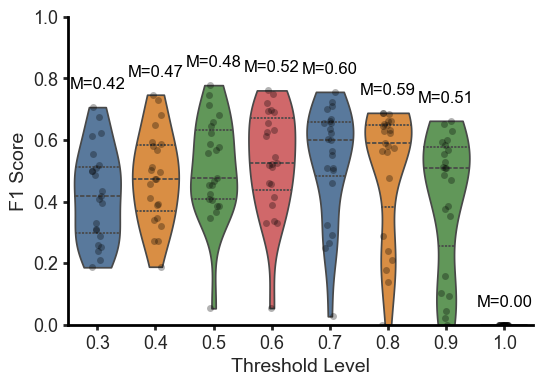

In [9]:
def plot_f1_violin_by_adapt(df, metric="F1", aggregate_by_network=False):
    # Define specific order
    # desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values = sorted(df["Threshold"].unique())

    # Data preparation
    if aggregate_by_network:
        # Average over sessions/channels for each network
        plot_df = df.groupby(["Network", "Threshold"])[metric].mean().reset_index()
        title_suffix = " (Averaged by Network)"
        print(f"Aggregated by network. N={len(plot_df['Network'].unique())} networks.")
    else:
        plot_df = df
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(6, 4))
    
    colors=["#4E79A7", "#F28E2B", "#59A14F", "#E15759"]

    # Violin plot
    sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)
    # Overlay points
    sns.stripplot(x="Threshold", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session", "Channel",]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Threshold", values=metric)
    # display(pivot.head())
    pivot = pivot.dropna()

    # Annotate medians and N
    medians = plot_df.groupby('Threshold')[metric].median()
    counts = plot_df.groupby('Threshold')[metric].count()
    mins=plot_df.groupby('Threshold')[metric].min() 
    maxs=plot_df.groupby('Threshold')[metric].max()
    for i, adapt in enumerate(adapt_values):
        if adapt in medians:
            val = medians[adapt]
            max_val = maxs[adapt]
            ax.text(i, max_val+ 0.05, f'M={val:.2f}',  
            ha='center', va='bottom', fontsize=12, color='black')

    if len(pivot) > 0:
        centers = range(len(adapt_values))
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3: 
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                print(f"{a1} vs {a2}: p={p:.4f}")
                # barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
                
    # ax.set_title(f"{metric} Distribution by Adaptation Level{title_suffix}")
    ax.set_ylim(0,1) 

    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(1.3)
    ax.spines[['bottom','left']].set_color('black')
    # ax.set_xticklabels(["Fixed","60", "10", "1"])
    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2)
    ax.tick_params(axis='x', rotation=0)

    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Threshold Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()
    return fig,ax

if 'df' in locals():
    fig,ax=plot_f1_violin_by_adapt(df, "F1", aggregate_by_network=False)
    os.makedirs("figures", exist_ok=True)
    # fig.savefig("figures/f1_violin_by_adapt.svg", dpi=300, bbox_inches='tight')
    # fig.savefig("figures/f1_violin_by_adapt.png",dpi=300)

C:\Users\NCN\AppData\Local\Temp\ipykernel_26808\1127962853.py:28: RuntimeWarning: divide by zero encountered in divide
  y = (f1 * x) / (2 * x - f1)


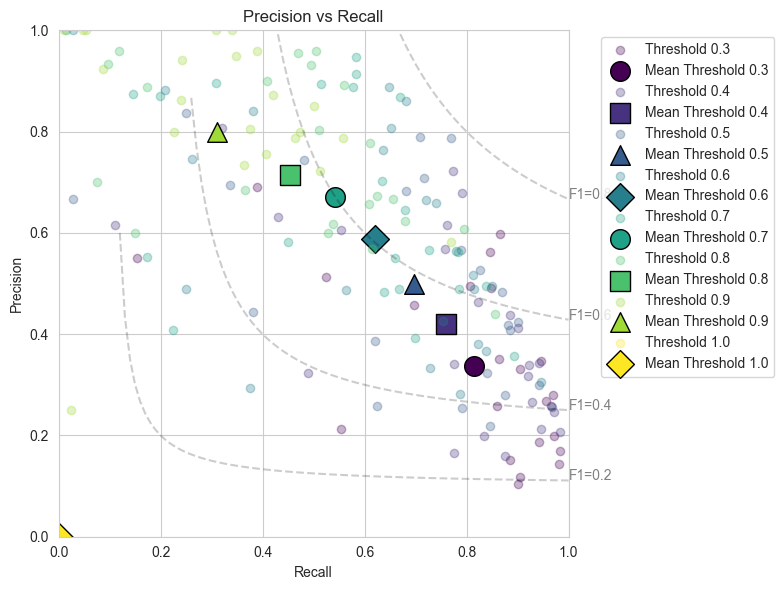

In [10]:
def plot_precision_recall(df):
    plt.figure(figsize=(8, 6))
    
    #  # Define specific order
    # desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values = sorted(df["Threshold"].unique())
    
    markers = ['o', 's', '^', 'D']
    colors = plt.cm.viridis(np.linspace(0, 1, len(adapt_values)))
    
    for i, adapt in enumerate(adapt_values):
        subset = df[df["Threshold"] == adapt]
        
        # Mean point
        mean_p = subset["Precision"].mean()
        mean_r = subset["Recall"].mean()
        
        plt.scatter(subset["Recall"], subset["Precision"], label=f"Threshold {adapt}", alpha=0.3, color=colors[i])
        plt.scatter(mean_r, mean_p, s=200, edgecolor='black', marker=markers[i%len(markers)], 
                    label=f"Mean Threshold {adapt}", color=colors[i])
        
    # F1 isolines
    f1_scores = [0.2, 0.4, 0.6, 0.8]
    x = np.linspace(0.01, 1, 100)
    for f1 in f1_scores:
        y = (f1 * x) / (2 * x - f1)
        # Filter valid y
        valid = (y >= 0) & (y <= 1)
        plt.plot(x[valid], y[valid], 'k--', alpha=0.2)
        if any(valid):
            plt.text(x[valid][-1], y[valid][-1], f"F1={f1}", color='gray')
        
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision vs Recall")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if 'df' in locals():
    plot_precision_recall(df)

C:\Users\NCN\AppData\Local\Temp\ipykernel_26808\3803571695.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Threshold", y="Percent Change", data=melted, palette="coolwarm", order=adapt_values)


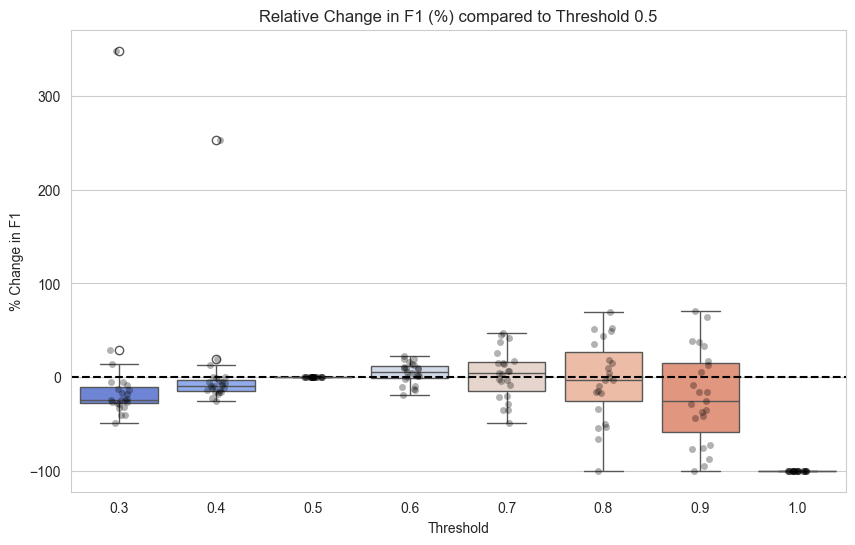

In [11]:
def plot_relative_change(df, metric="F1"):
    # Pivot to have Adapt as columns
    pivot_cols = ["Session", "Channel",]
    if "Dataset" in df.columns:
        pivot_cols.append("Dataset")
        
    pivot = df.pivot_table(index=pivot_cols, columns="Threshold", values=metric) # Pivot table
    # print(pivot.head())
    # Calculate change relative to Adapt 0 (or lowest adapt value)
     # Define specific order
    desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values= sorted(df["Threshold"].unique())
    baseline_adapt = 0.5
    
    if baseline_adapt not in pivot.columns:
        print(f"Baseline adapt {baseline_adapt} not found in pivot columns.")
        return

    changes = pd.DataFrame()
    for col in pivot.columns:
        changes[col] = (pivot[col] - pivot[baseline_adapt]) / pivot[baseline_adapt] * 100
        
    # Melt for plotting
    melted = changes.melt(var_name="Threshold", value_name="Percent Change")
    # print(melted)
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="Threshold", y="Percent Change", data=melted, palette="coolwarm", order=adapt_values)
    # Overlay points
    sns.stripplot(x="Threshold", y="Percent Change", data=melted, color="black", alpha=0.3, jitter=True, order=adapt_values)

    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"Relative Change in {metric} (%) compared to Threshold {baseline_adapt}")
    plt.ylabel(f"% Change in {metric}")
    plt.show()

if 'df' in locals():
    plot_relative_change(df, "F1")

,Session,Channel,Threshold,Metric,Value
0,2025-09-22_17-42-27,24,0.5,Precision,0.709091
1,2025-09-24_10-24-40,30,0.5,Precision,0.443038
2,2025-09-23_15-50-26,28,0.5,Precision,0.744444
3,2025-09-24_11-34-51,30,0.5,Precision,0.385965
4,2025-09-24_16-29-07,5,0.5,Precision,0.257732


C:\Users\NCN\AppData\Local\Temp\ipykernel_26808\1095338557.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Metric', y='Value', data=melted, ax=ax, palette='viridis', inner='quartile', cut=0, order=order,alpha=.8,linewidth=2)


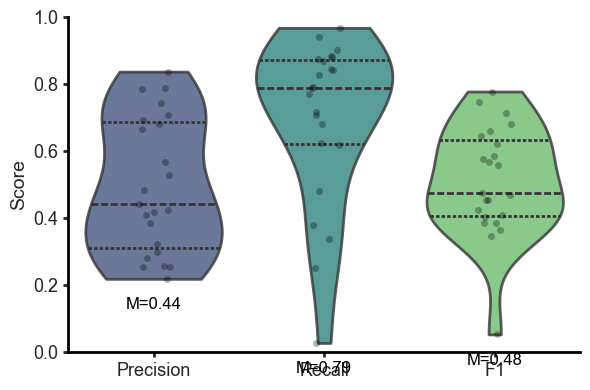

In [12]:
# Plot Precision, Recall and F1 for a single Adaptation level in the same figure
def plot_metrics_single_adapt(df, adapt=20, aggregate_by_network=False, metrics=("Precision", "Recall", "F1")):
    """Plot the distributions of multiple metrics for a single `adapt` value in one plot."""
    # Ensure adapt exists in the dataframe
    if adapt not in df["Threshold"].unique():
        print(f"Adapt {adapt} not present in dataframe. Available: {sorted(df['Threshold'].unique())}")
        return

    # Prepare data for the requested adapt
    if aggregate_by_network:
        agg_cols = ['Network', 'Adapt']
        plot_df = df.groupby(agg_cols)[list(metrics)].mean().reset_index()
        title_suffix = ' (Averaged by Network)'
    else:
        plot_df = df.copy()
        title_suffix = ''

    plot_df = plot_df[plot_df['Threshold'] == adapt]
    if len(plot_df) == 0:
        print(f'No rows for Threshold {adapt} after filtering.')
        return

    # Melt metrics into long form for plotting
    id_vars = [c for c in ['Session', 'Channel', 'Threshold'] if c in plot_df.columns]
    melted = plot_df.melt(id_vars=id_vars, value_vars=list(metrics), var_name='Metric', value_name='Value')
    display(melted.head())
    # Plot
    fig, ax = plt.subplots(figsize=(6, 4))
    order = list(metrics)
    sns.violinplot(x='Metric', y='Value', data=melted, ax=ax, palette='viridis', inner='quartile', cut=0, order=order,alpha=.8,linewidth=2)
    sns.stripplot(x='Metric', y='Value', data=melted, ax=ax, color='k', alpha=0.3, jitter=True, order=order)

    # Annotate medians and N
    medians = melted.groupby('Metric')['Value'].median()
    counts = melted.groupby('Metric')['Value'].count()
    mins=melted.groupby('Metric')['Value'].min() 
    
    for i, metric in enumerate(order):
        if metric in medians:
            val = medians[metric]
            min_val = mins[metric]
            ax.text(i, min_val- 0.1, f'M={val:.2f}',  
            ha='center', va='bottom', fontsize=12, color='black')

    ax.set_ylim(0, 1)
    # ax.set_title(f'Performance Metrics', fontsize=14)
    ax.set_ylabel('Score', fontsize=14)
    ax.set_xlabel('')
    # ax.set_xlabel('Metric', fontsize=14)
    # ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.4)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')

    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2.0)
    ax.tick_params(axis='x', rotation=0)
    # ax.set_yticks(np.arange(0.3, 1.1, 0.1))
    plt.tight_layout()
    plt.show()
    return fig, ax

if 'df' in locals():
    fig,ax=plot_metrics_single_adapt(df, adapt=0.5, aggregate_by_network=False)
    # plot_f1_violin_by_adapt(df, "F1", aggregate_by_network=False)
    # fig.savefig("figures/metrics_single_adapt.svg", format="svg")
    # fig.savefig("figures/metrics_single_adapt.png", format="png", dpi=300)

Optimizing metrics over: ['Threshold']
Original rows: 184, Optimized rows: 23

--- Optimized Performance Summary (Best Threshold Per Session) ---


,F1,Precision,Recall
count,23.000,23.000,23.000
mean,0.607,0.649,0.604
std,0.132,0.150,0.157
min,0.239,0.258,0.153
25%,0.549,0.556,0.531
50%,0.648,0.658,0.625
75%,0.691,0.770,0.705
max,0.778,0.889,0.813


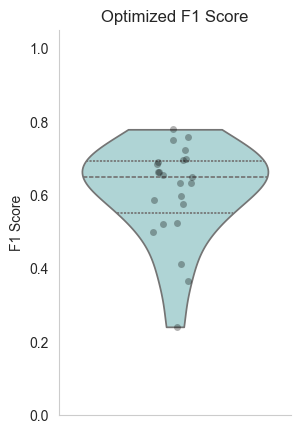

In [13]:
# Compute the performance considering the best configuration per session
def compute_best_performance(df, metric="F1", optimize=["Threshold", "Model", "Network"], average_over=["Channel"]):
    """
    Computes the best performance for each session by selecting the configuration (Threshold, Model, etc.)
    that maximizes the given metric.
    """
    # 1. Validate columns
    optimize = [col for col in optimize if col in df.columns]
    
    if not optimize:
        print("No columns to optimize found.")
        return df

    print(f"Optimizing metrics over: {optimize}")

    # 2. Group by Session and Optimization parameters to find mean performance (e.g. across channels)
    group_cols = ["Session"] + optimize
    
    # Calculate the mean score of the target metric for each configuration
    performance_per_config = df.groupby(group_cols)[metric].mean().reset_index()

    # 3. select the best configuration for each session
    best_configs = performance_per_config.sort_values(by=[metric], ascending=False).drop_duplicates(subset=["Session"])

    # 4. Merge back to get the full rows (metrics per channel) for the best configs
    best_performance_df = df.merge(best_configs[group_cols], on=group_cols, how="inner")
    
    # Print stats
    print(f"Original rows: {len(df)}, Optimized rows: {len(best_performance_df)}")
    
    return best_performance_df

if 'df' in locals():
    # Run optimization (Optimizing Threshold)
    df_opt = compute_best_performance(df, optimize=["Threshold"])
    
    # Show Summary
    print("\n--- Optimized Performance Summary (Best Threshold Per Session) ---")
    display(df_opt[["F1", "Precision", "Recall"]].describe().round(3))
    
    # Visualization
    fig, ax = plt.subplots(figsize=(3, 5))
    sns.violinplot(y="F1", data=df_opt, color="#a8dadc", inner="quartile", ax=ax, cut=0)
    sns.stripplot(y="F1", data=df_opt, color="black", alpha=0.3, ax=ax)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1 Score")
    ax.set_title("Optimized F1 Score")
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.show()